# Notebook 01 — Exploratory Data Analysis
**Project:** Fraud Detection ML — Sparkov Simulated Transactions  
**Dataset:** `fraudTrain.csv` + `fraudTest.csv` (~1.3M transactions)  
**Goal:** Understand the shape of the data, identify fraud patterns, and generate the plots we need for the Tableau dashboard.

EDA is not just a formality — it tells us which features are worth engineering and what model decisions we need to make. In fraud ops, this is the equivalent of a first-look investigation before opening a case queue.

## Cell 1 — Imports and Configuration
We load all the libraries we need upfront and set consistent display/plot settings.  
- **pandas** — the main tool for loading and manipulating tabular data  
- **numpy** — fast numerical operations  
- **matplotlib / seaborn** — plotting libraries (seaborn builds on matplotlib with nicer defaults)  
- **pathlib.Path** — cleaner way to handle file paths across operating systems  

We also define `DATA_RAW` and `DATA_PROCESSED` as path constants at the top so we never hardcode paths deeper in the notebook.

In [ ]:
import sys
print(sys.executable)


c:\Users\34673\OneDrive\IRONHACK BOOTCAMP1\EXERCISES\WEEK8\PROJECT_FRAUD_DETECTION\fraud-detection-project\venv\Scripts\python.exe


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Display settings 
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

# Plot settings 
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

# Path constants — change only here if folders move 
DATA_RAW       = Path('../data/raw')
DATA_PROCESSED = Path('../data/processed')
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)  # create if missing

print('Imports complete.')
print(f'Raw data path:       {DATA_RAW.resolve()}')
print(f'Processed data path: {DATA_PROCESSED.resolve()}')

Imports complete.
Raw data path:       C:\Users\34673\OneDrive\IRONHACK BOOTCAMP1\EXERCISES\WEEK8\PROJECT_FRAUD_DETECTION\fraud-detection-project\data\raw
Processed data path: C:\Users\34673\OneDrive\IRONHACK BOOTCAMP1\EXERCISES\WEEK8\PROJECT_FRAUD_DETECTION\fraud-detection-project\data\processed


## Cell 2 — Load Data
We load both the training and test CSV files. In fraud detection it is important to keep them separate from the very beginning — we never want information from the test set to influence our understanding of the training data.

We print shape (rows × columns), column data types, and the first 3 rows of the training set to confirm the load was successful.

In [4]:
# Load raw CSV files
train = pd.read_csv(DATA_RAW / 'fraudTrain.csv')
test  = pd.read_csv(DATA_RAW / 'fraudTest.csv')

# Shapes 
print(f'Train shape: {train.shape}')  # expect ~1.3M rows, 23 columns
print(f'Test shape:  {test.shape}')   # expect ~555K rows, 23 columns

# Column types 
print('\nData types:')
print(train.dtypes)

# First 5 rows 
print('\nFirst 5 rows of training set:')
train.head(5)

Train shape: (1296675, 23)
Test shape:  (555719, 23)

Data types:
Unnamed: 0                 int64
trans_date_trans_time     object
cc_num                     int64
merchant                  object
category                  object
amt                      float64
first                     object
last                      object
gender                    object
street                    object
city                      object
state                     object
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                       object
dob                       object
trans_num                 object
unix_time                  int64
merch_lat                float64
merch_long               float64
is_fraud                   int64
dtype: object

First 3 rows of training set:


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.9700,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.0113,-82.0483,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.2300,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.1590,-118.1865,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.1100,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.1507,-112.1545,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.0000,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.0343,-112.5611,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.9600,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.6750,-78.6325,0


In [8]:
print(train['merchant'].unique()[:20])

['fraud_Rippin, Kub and Mann' 'fraud_Heller, Gutmann and Zieme'
 'fraud_Lind-Buckridge' 'fraud_Kutch, Hermiston and Farrell'
 'fraud_Keeling-Crist' 'fraud_Stroman, Hudson and Erdman'
 'fraud_Rowe-Vandervort' 'fraud_Corwin-Collins' 'fraud_Herzog Ltd'
 'fraud_Schoen, Kuphal and Nitzsche' 'fraud_Rutherford-Mertz'
 'fraud_Kerluke-Abshire' 'fraud_Lockman Ltd' 'fraud_Kiehn Inc'
 'fraud_Beier-Hyatt' 'fraud_Schmidt and Sons' 'fraud_Lebsack and Sons'
 'fraud_Mayert Group' 'fraud_Konopelski, Schneider and Hartmann'
 'fraud_Schultz, Simonis and Little']


## Cell 3 — Missing Values
Before building any features or models we need to know if the data is complete.  
Missing values can silently break pipelines or skew statistics — always check first.

In Sparkov this dataset is simulation-generated so we expect zero nulls, but we verify rather than assume.

In [9]:
# Count nulls per column and show as a clean table
null_summary = pd.DataFrame({
    'missing_count': train.isnull().sum(),
    'missing_pct':   (train.isnull().sum() / len(train) * 100).round(4)
})

print('Missing value summary (training set):')
print(null_summary[null_summary['missing_count'] > 0])  # only show columns with nulls

if null_summary['missing_count'].sum() == 0:
    print('No missing values found. Dataset is complete.')

Missing value summary (training set):
Empty DataFrame
Columns: [missing_count, missing_pct]
Index: []
No missing values found. Dataset is complete.


## Cell 3b — Duplicate Check
We check for two types of duplicates:
- **Fully duplicate rows** — every column identical (would mean the same transaction appeared twice)
- **Duplicate `trans_num`** — same transaction ID appearing more than once (the unique key for each transaction)

Sparkov is a simulated dataset so we expect zero duplicates, but we verify explicitly rather than assume. In real payments data, duplicates can appear from retry logic, ETL errors, or double-posting bugs — catching them in EDA prevents them from inflating training counts.

In [10]:
# Check 1: fully duplicate rows (every column identical)
full_dupes = train.duplicated().sum()
print(f"Fully duplicate rows:       {full_dupes:,}")

# Check 2: duplicate transaction IDs (trans_num is the unique transaction key)
trans_num_dupes = train["trans_num"].duplicated().sum()
print(f"Duplicate trans_num values: {trans_num_dupes:,}")

# Check both datasets
full_dupes_test      = test.duplicated().sum()
trans_num_dupes_test = test["trans_num"].duplicated().sum()
print(f"\nTest set -- fully duplicate rows:       {full_dupes_test:,}")
print(f"Test set -- duplicate trans_num values: {trans_num_dupes_test:,}")

# Summary
if full_dupes == 0 and trans_num_dupes == 0 and full_dupes_test == 0 and trans_num_dupes_test == 0:
    print("\nNo duplicates found in either dataset. Data integrity confirmed.")
else:
    print("\nWARNING: Duplicates detected -- investigate before proceeding.")


Fully duplicate rows:       0
Duplicate trans_num values: 0

Test set -- fully duplicate rows:       0
Test set -- duplicate trans_num values: 0

No duplicates found in either dataset. Data integrity confirmed.


## Cell 4 — Class Imbalance **Most Important Cell**
The fraud rate in this dataset is ~0.58% — meaning for every 1 fraud transaction there are ~172 legitimate ones. This extreme imbalance is the single most important data characteristic for every decision we make downstream:

- **Accuracy is useless as a metric** — a model that predicts "legit" for everything gets 99.4% accuracy but catches zero fraud
- **We must use Precision-Recall AUC** as our primary metric, not ROC-AUC (which is optimistic under imbalance)
- **We will apply SMOTE** on the training set to synthetically oversample the minority class before training
- In real ops at Stripe, this imbalance is even more extreme — fraud teams work queues of ~1 in 500–1000 transactions

This chart will also go into the Tableau dashboard as one of the three required visualisations.

Total transactions:  1,296,675
Fraudulent:          7,506  (0.5789%)
Legitimate:          1,289,169  (99.4211%)


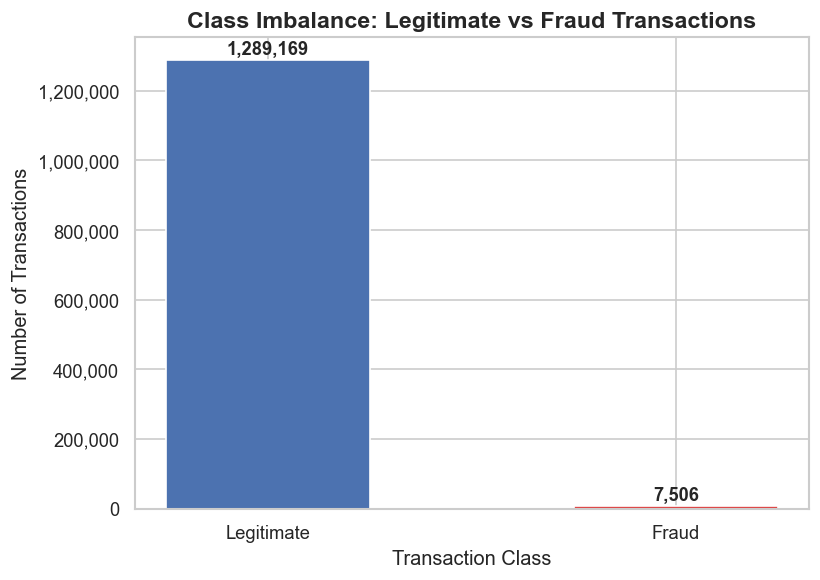

Saved: plot_class_balance.png


In [11]:
# Calculate fraud rate 
fraud_count  = train['is_fraud'].sum()
legit_count  = len(train) - fraud_count
fraud_rate   = train['is_fraud'].mean() * 100

print(f'Total transactions:  {len(train):,}')
print(f'Fraudulent:          {fraud_count:,}  ({fraud_rate:.4f}%)')
print(f'Legitimate:          {legit_count:,}  ({100 - fraud_rate:.4f}%)')

# Bar chart 
fig, ax = plt.subplots(figsize=(7, 5))

labels = ['Legitimate', 'Fraud']
counts = [legit_count, fraud_count]
colors = ['#4C72B0', '#DD4444']

bars = ax.bar(labels, counts, color=colors, width=0.5, edgecolor='white')

# Add count labels on top of each bar
for bar, count in zip(bars, counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5000,
        f'{count:,}',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

ax.set_title('Class Imbalance: Legitimate vs Fraud Transactions', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Transactions')
ax.set_xlabel('Transaction Class')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'plot_class_balance.png', dpi=120)
plt.show()
print('Saved: plot_class_balance.png')

## Cell 5 — Transaction Amount Distribution
Fraudulent transactions often have a distinct amount pattern compared to legitimate ones.  
We plot the raw amount and the log-transformed amount side by side:

- **Raw amount** shows the actual scale but is dominated by a few large values (right-skewed)
- **Log-transformed** compresses the scale so we can see the shape of both distributions clearly

This matters for feature engineering — `log(amount)` is often more informative than raw `amount` for tree-based models.

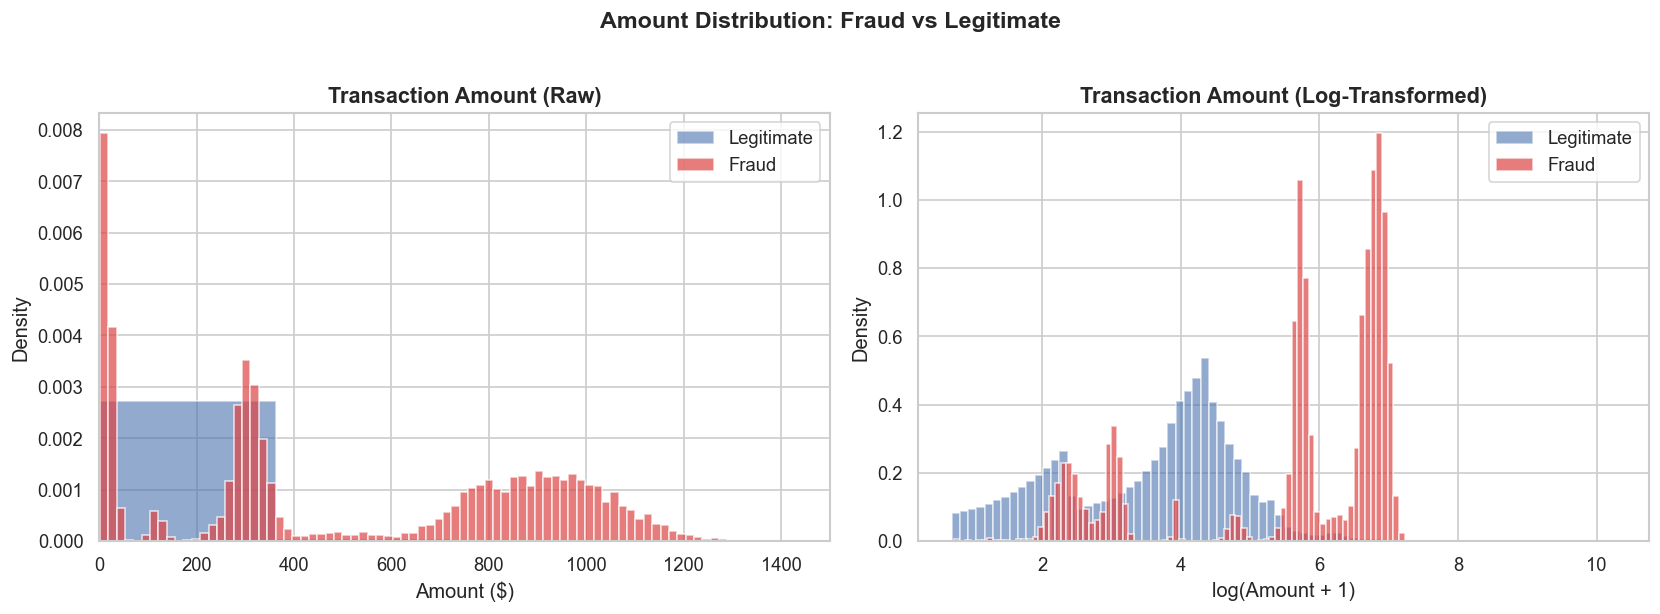

Saved: plot_amount_dist.png


In [12]:
# Separate fraud and legit for colour-coded plotting
fraud = train[train['is_fraud'] == 1]
legit = train[train['is_fraud'] == 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: raw amount 
axes[0].hist(legit['amt'], bins=80, color='#4C72B0', alpha=0.6, label='Legitimate', density=True)
axes[0].hist(fraud['amt'], bins=80, color='#DD4444', alpha=0.7, label='Fraud',      density=True)
axes[0].set_title('Transaction Amount (Raw)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].set_xlim(0, 1500)  # cap at $1500 for readability

# Right: log-transformed amount 
axes[1].hist(np.log1p(legit['amt']), bins=80, color='#4C72B0', alpha=0.6, label='Legitimate', density=True)
axes[1].hist(np.log1p(fraud['amt']), bins=80, color='#DD4444', alpha=0.7, label='Fraud',      density=True)
axes[1].set_title('Transaction Amount (Log-Transformed)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('log(Amount + 1)')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.suptitle('Amount Distribution: Fraud vs Legitimate', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'plot_amount_dist.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: plot_amount_dist.png')

## Cell 6 — Fraud Rate by Merchant Category
Different merchant categories carry very different fraud risk. We calculate fraud rate per category (not raw count — raw count would just reflect how common the category is).

**From a Stripe fraud ops perspective:**  
- **Shopping / online retail** is high risk because it's card-not-present (CNP) — the physical card is never verified  
- **Grocery and gas** are frequently targeted because fraudsters test stolen cards with small, plausible transactions before cashing out  
- **Entertainment / travel** transactions are harder to dispute and often have higher ticket sizes  

This chart goes into the Tableau dashboard as one of the three required visualisations.

Fraud rate by category:
                fraud_rate_pct  fraud_count   total
category                                           
shopping_net            1.7561         1713   97543
misc_net                1.4458          915   63287
grocery_pos             1.4098         1743  123638
shopping_pos            0.7225          843  116672
gas_transport           0.4694          618  131659
misc_pos                0.3139          250   79655
grocery_net             0.2948          134   45452
travel                  0.2864          116   40507
entertainment           0.2478          233   94014
personal_care           0.2424          220   90758
kids_pets               0.2114          239  113035
food_dining             0.1651          151   91461
home                    0.1608          198  123115
health_fitness          0.1549          133   85879


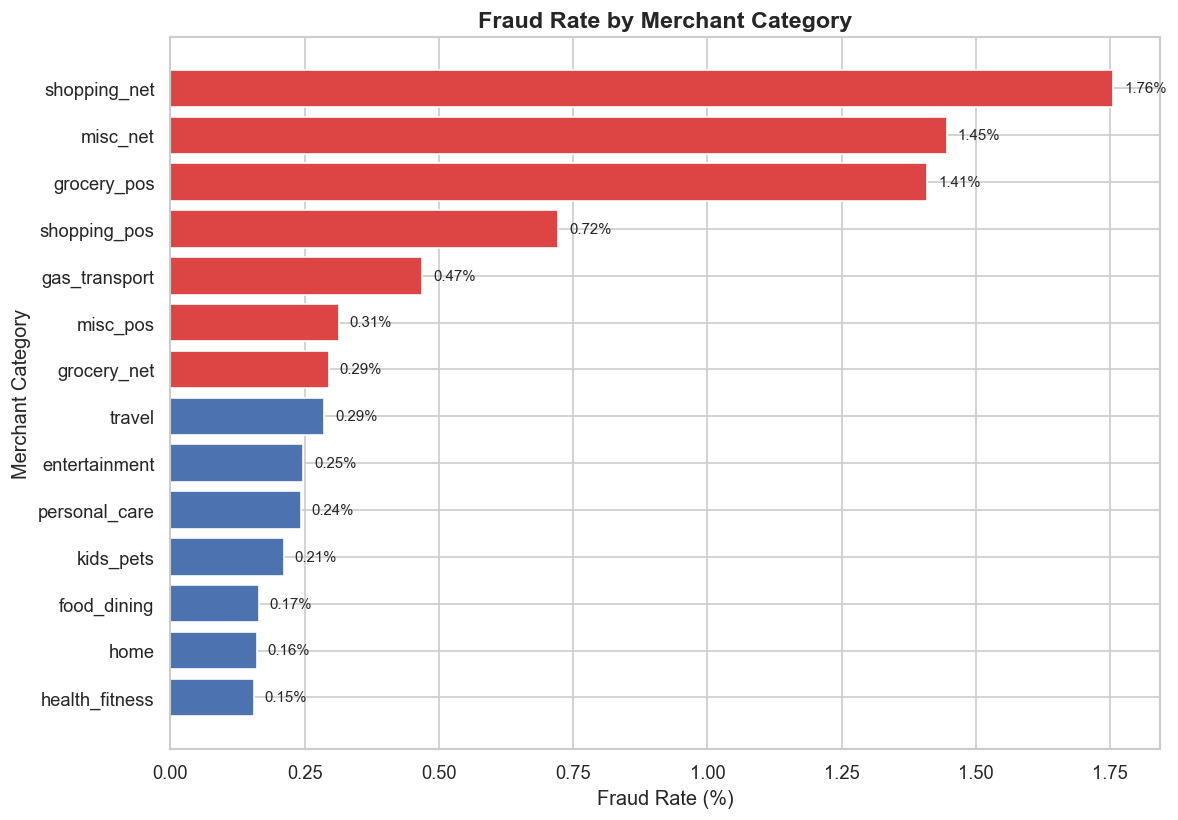

Saved: plot_fraud_by_category.png


In [13]:
# Calculate fraud rate per category
category_fraud = (
    train.groupby('category')['is_fraud']
    .agg(['mean', 'sum', 'count'])
    .rename(columns={'mean': 'fraud_rate', 'sum': 'fraud_count', 'count': 'total'})
    .sort_values('fraud_rate', ascending=True)  # ascending for horizontal bar chart
)
category_fraud['fraud_rate_pct'] = category_fraud['fraud_rate'] * 100

print('Fraud rate by category:')
print(category_fraud[['fraud_rate_pct', 'fraud_count', 'total']].sort_values('fraud_rate_pct', ascending=False))

# Horizontal bar chart 
fig, ax = plt.subplots(figsize=(10, 7))

colors = ['#DD4444' if r > category_fraud['fraud_rate_pct'].median() else '#4C72B0'
          for r in category_fraud['fraud_rate_pct']]

bars = ax.barh(category_fraud.index, category_fraud['fraud_rate_pct'], color=colors, edgecolor='white')

# Add percentage labels
for bar, val in zip(bars, category_fraud['fraud_rate_pct']):
    ax.text(val + 0.02, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}%', va='center', fontsize=9)

ax.set_title('Fraud Rate by Merchant Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Fraud Rate (%)')
ax.set_ylabel('Merchant Category')

plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'plot_fraud_by_category.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: plot_fraud_by_category.png')

## Cell 7 — Fraud Rate by Hour of Day
Fraud has a strong temporal signature. We extract the hour from the transaction timestamp and plot fraud rate across the 24-hour cycle.

**Why this matters operationally:**  
- Late-night hours (midnight–4am) consistently show elevated fraud rates in real payments data  
- Legitimate cardholders are asleep; fraudsters are not — they often run automated scripts overnight  
- At Stripe, `hour_of_day` is one of the first features fraud rules teams reach for when writing velocity rules  
- This feature will be one of our engineered columns in notebook 02

This chart goes into the Tableau dashboard as the third required visualisation.

Fraud rate by hour:
      fraud_rate_pct  total_txns
hour                            
0             1.4940       42502
1             1.5349       42869
2             1.4652       42656
3             1.4239       42769
4             0.1099       41863
5             0.1423       42171
6             0.0946       42300
7             0.1327       42203
8             0.1153       42505
9             0.1114       42185
10            0.0946       42271
11            0.0998       42082
12            0.1027       65257
13            0.1225       65314
14            0.1325       64885
15            0.1208       65391
16            0.1156       65726
17            0.1192       65450
18            0.1226       66051
19            0.1236       65508
20            0.0952       65098
21            0.1129       65533
22            2.8829       66982
23            2.8374       67104


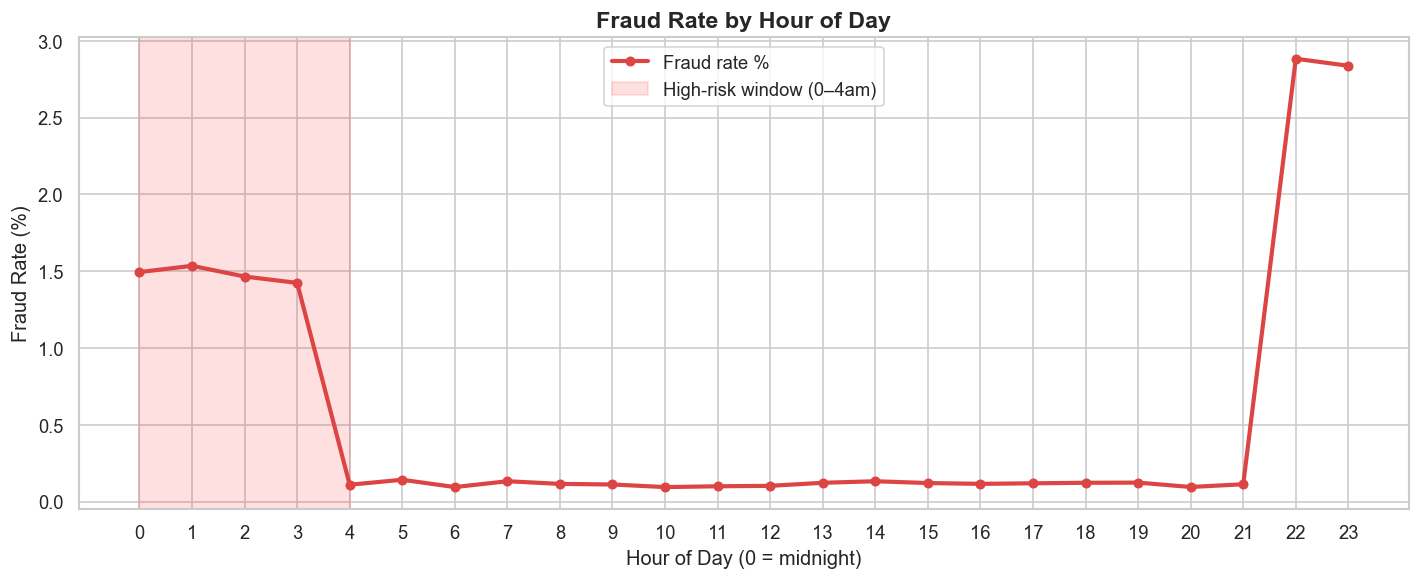

Saved: plot_fraud_by_hour.png


In [14]:
# Parse datetime and extract hour
train['trans_datetime'] = pd.to_datetime(train['trans_date_trans_time'])
train['hour'] = train['trans_datetime'].dt.hour

# Fraud rate per hour
hourly_fraud = (
    train.groupby('hour')['is_fraud']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'fraud_rate', 'count': 'total_txns'})
)
hourly_fraud['fraud_rate_pct'] = hourly_fraud['fraud_rate'] * 100

print('Fraud rate by hour:')
print(hourly_fraud[['fraud_rate_pct', 'total_txns']])

# Line chart 
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(hourly_fraud.index, hourly_fraud['fraud_rate_pct'],
        color='#DD4444', linewidth=2.5, marker='o', markersize=5, label='Fraud rate %')

# Shade the high-risk window (midnight to 4am)
ax.axvspan(0, 4, alpha=0.12, color='red', label='High-risk window (0–4am)')

ax.set_title('Fraud Rate by Hour of Day', fontsize=14, fontweight='bold')
ax.set_xlabel('Hour of Day (0 = midnight)')
ax.set_ylabel('Fraud Rate (%)')
ax.set_xticks(range(24))
ax.legend()

plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'plot_fraud_by_hour.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: plot_fraud_by_hour.png')

## Cell 8 — Transaction Amount: Fraud vs Legitimate (Boxplot)
Boxplots let us compare the distribution of transaction amounts for fraud vs. legitimate transactions beyond just the mean — we can see the median, quartiles, and outliers.

We use log-scale on the y-axis to prevent extreme outliers from collapsing the boxes into a flat line.

C:\Users\34673\AppData\Local\Temp\ipykernel_12816\1113009176.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


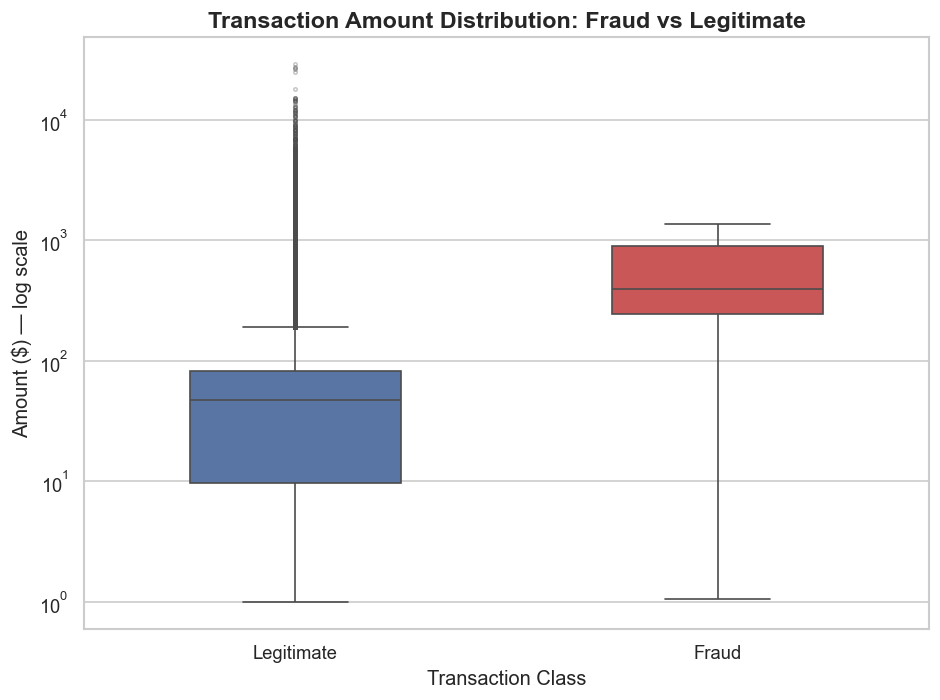

Saved: plot_amount_boxplot.png


In [15]:
# Create a readable label column for the plot
plot_data = train.copy()
plot_data['label'] = plot_data['is_fraud'].map({0: 'Legitimate', 1: 'Fraud'})

fig, ax = plt.subplots(figsize=(8, 6))

sns.boxplot(
    data=plot_data,
    x='label',
    y='amt',
    palette={'Legitimate': '#4C72B0', 'Fraud': '#DD4444'},
    order=['Legitimate', 'Fraud'],
    width=0.5,
    flierprops=dict(marker='o', markersize=2, alpha=0.3),
    ax=ax
)

ax.set_yscale('log')  # log scale so outliers don't squash the boxes
ax.set_title('Transaction Amount Distribution: Fraud vs Legitimate', fontsize=14, fontweight='bold')
ax.set_xlabel('Transaction Class')
ax.set_ylabel('Amount ($) — log scale')

plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'plot_amount_boxplot.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: plot_amount_boxplot.png')

## Cell 9 — Top 10 States by Fraud Rate
Geographic patterns can reveal regional fraud clusters. We calculate fraud rate per US state (not raw count — population size varies by state) and plot the top 10.

This is also useful for thinking about the `geo_distance` feature we will engineer in notebook 02 — the distance between the cardholder's registered address and the merchant location.

Top 10 states by fraud rate:
       fraud_rate_pct  fraud_count  total
state                                    
RI             2.7273           15    550
AK             1.6981           36   2120
NV             0.8382           47   5607
CO             0.8141          113  13880
OR             0.8012          149  18597
TN             0.7975          140  17554
NE             0.7448          180  24168
ME             0.7210          119  16505
NH             0.7127           59   8278
OH             0.6906          321  46480


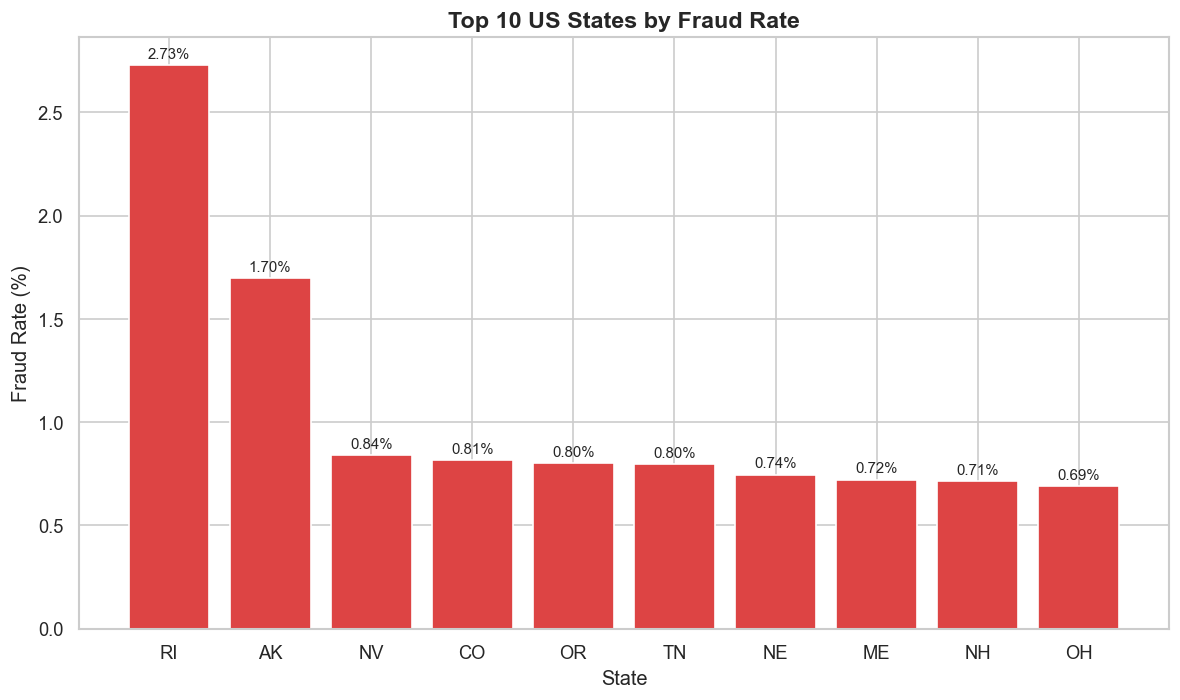

Saved: plot_fraud_by_state.png


In [16]:
# Fraud rate per state, keep only states with >100 transactions to avoid noise
state_fraud = (
    train.groupby('state')['is_fraud']
    .agg(['mean', 'sum', 'count'])
    .rename(columns={'mean': 'fraud_rate', 'sum': 'fraud_count', 'count': 'total'})
)
state_fraud = state_fraud[state_fraud['total'] > 100]  # filter low-volume states
state_fraud['fraud_rate_pct'] = state_fraud['fraud_rate'] * 100
top10_states = state_fraud.nlargest(10, 'fraud_rate_pct')

print('Top 10 states by fraud rate:')
print(top10_states[['fraud_rate_pct', 'fraud_count', 'total']])

# Bar chart 
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    top10_states.index,
    top10_states['fraud_rate_pct'],
    color='#DD4444',
    edgecolor='white'
)

for bar, val in zip(bars, top10_states['fraud_rate_pct']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=9)

ax.set_title('Top 10 US States by Fraud Rate', fontsize=14, fontweight='bold')
ax.set_xlabel('State')
ax.set_ylabel('Fraud Rate (%)')

plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'plot_fraud_by_state.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: plot_fraud_by_state.png')

## Cell 10 — Correlation Matrix
A correlation heatmap shows us which numeric features move together with `is_fraud`. We include `amt`, `city_pop`, `hour`, and `is_fraud`.

Note: correlation only captures **linear** relationships. XGBoost will find non-linear ones. But this is a useful starting point — a low correlation doesn't mean a feature is useless, and a high correlation doesn't guarantee it will be the best predictor.

Correlation matrix:
             amt  city_pop    hour  is_fraud
amt       1.0000    0.0058 -0.0228    0.2194
city_pop  0.0058    1.0000  0.0204    0.0021
hour     -0.0228    0.0204  1.0000    0.0138
is_fraud  0.2194    0.0021  0.0138    1.0000


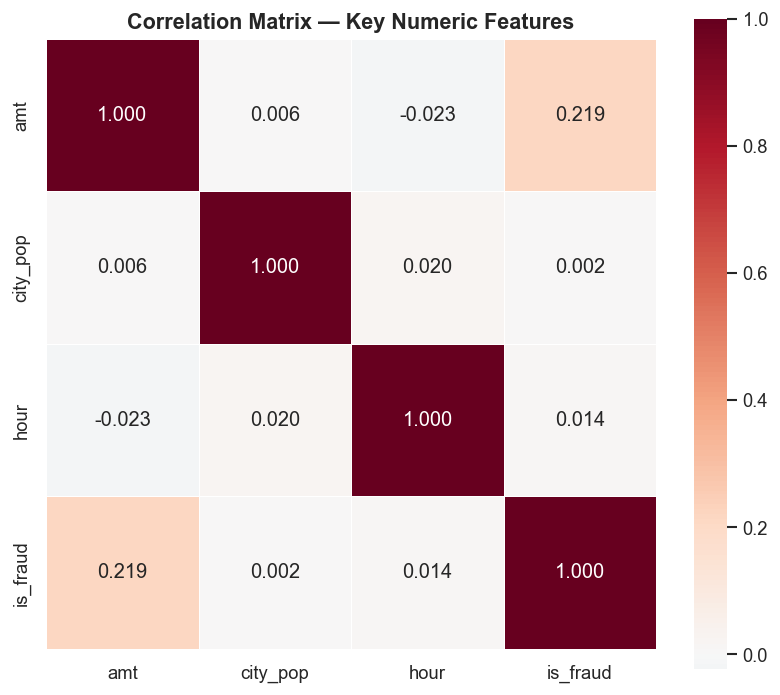

Saved: plot_correlation.png


In [17]:
# Select numeric features relevant for correlation
corr_cols = ['amt', 'city_pop', 'hour', 'is_fraud']
corr_matrix = train[corr_cols].corr()

print('Correlation matrix:')
print(corr_matrix.round(4))

# Heatmap 
fig, ax = plt.subplots(figsize=(7, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.3f',
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax
)

ax.set_title('Correlation Matrix — Key Numeric Features', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'plot_correlation.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: plot_correlation.png')

## Cell 11 — EDA Summary Statistics
A final structured summary of the dataset to capture in one place the numbers we will reference throughout the rest of the project.

In [18]:
# Date range 
date_min = train['trans_datetime'].min()
date_max = train['trans_datetime'].max()

# Amount stats split by class 
avg_fraud_amt = train[train['is_fraud'] == 1]['amt'].mean()
avg_legit_amt = train[train['is_fraud'] == 0]['amt'].mean()

# Print summary 
print('=' * 50)
print('EDA SUMMARY — SPARKOV FRAUD DATASET')
print('=' * 50)
print(f'Total transactions:       {len(train):>12,}')
print(f'Fraud transactions:       {train["is_fraud"].sum():>12,}')
print(f'Fraud rate:               {train["is_fraud"].mean()*100:>11.4f}%')
print(f'Date range:               {date_min.date()} → {date_max.date()}')
print(f'Unique merchants:         {train["merchant"].nunique():>12,}')
print(f'Unique categories:        {train["category"].nunique():>12,}')
print(f'Avg fraud amount:         ${avg_fraud_amt:>11.2f}')
print(f'Avg legitimate amount:    ${avg_legit_amt:>11.2f}')
print('=' * 50)

EDA SUMMARY — SPARKOV FRAUD DATASET
Total transactions:          1,296,675
Fraud transactions:              7,506
Fraud rate:                    0.5789%
Date range:               2019-01-01 → 2020-06-21
Unique merchants:                  693
Unique categories:                  14
Avg fraud amount:         $     531.32
Avg legitimate amount:    $      67.67


## Key EDA Findings — Impact on Feature Engineering

Three findings from this EDA will directly shape the decisions in notebook 02 (feature engineering):

---

### Finding 1 — Severe class imbalance (0.58% fraud rate)
We cannot use raw accuracy as a metric. We will use **Precision-Recall AUC** throughout. We will apply **SMOTE on the training set only** to oversample the minority class before model training. This is the most structurally important fact about this dataset.

---

### Finding 2 — Time of day has a strong fraud signal
The fraud rate spikes sharply between midnight and 4am. This means **`hour_of_day`** should be one of our engineered features in notebook 02. It is a well-known signal in real fraud operations — legitimate cardholders have sleep patterns, automated fraud bots do not.

---

### Finding 3 — Merchant category and geography are discriminative
Some categories (shopping online, entertainment) have fraud rates several times higher than others (grocery, travel). Combined with geographic features — specifically the **distance between the cardholder's home address and the merchant location** — these will form the core of our feature engineering. A transaction at a shopping_net merchant, at 2am, 500km from the cardholder's registered address, is a very different risk profile than a grocery store transaction at 9am two streets away.